# **COMPETITION- Image Classification**

### Download and loading the dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load image data and labels
data = np.load("D:\Image Classification\cifar10.1_v6_data.npy")
labels = np.load("D:\Image Classification\cifar10.1_v6_labels.npy")

# Check shape
print(f"Data Shape: {data.shape}")  
print(f"Labels Shape: {labels.shape}") 

Data Shape: (2000, 32, 32, 3)
Labels Shape: (2000,)


### Visualizing the dataset

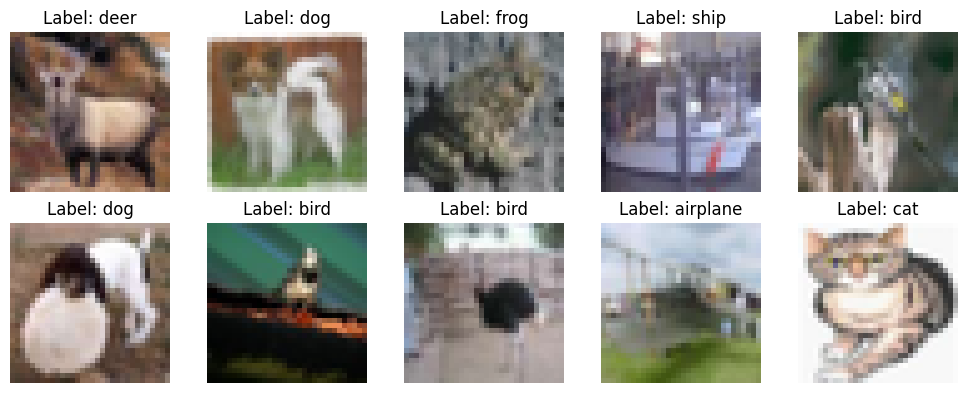

In [3]:
# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Randomly select 10 indices
indices = np.random.choice(len(data), size=10, replace=False)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(data[idx])
    ax.set_title(f"Label: {class_names[labels[idx]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Analyze class distribution

##### To ensure balanced training, check how each class is distributed.

In [4]:
import collections

# Count occurrences of each label
label_counts = collections.Counter(labels)

# Display distribution
print("Class Distribution:", label_counts)

Class Distribution: Counter({np.int32(0): 200, np.int32(1): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(6): 200, np.int32(7): 200, np.int32(8): 200, np.int32(9): 200})


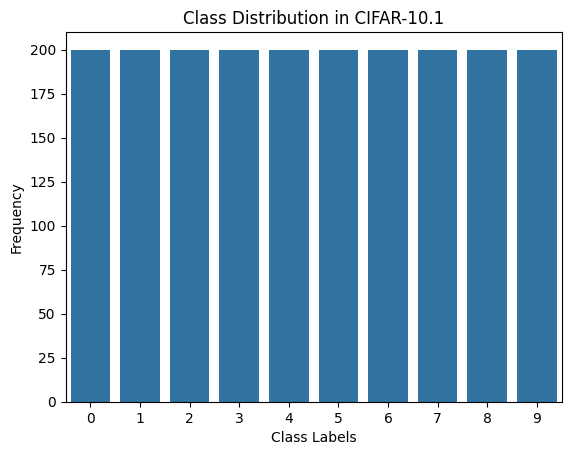

In [5]:
import seaborn as sns

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.xlabel("Class Labels")
plt.ylabel("Frequency")
plt.title("Class Distribution in CIFAR-10.1")
plt.show()

##### According to the above analysis, this confirms that the classes are ***evenly distributed.***

In [6]:
print(f"Min pixel value: {data.min()}")
print(f"Max pixel value: {data.max()}")

Min pixel value: 0
Max pixel value: 255


Since pixel values in images typically range from 0 to 255, ***normalization*** ensures they are scaled to a more manageable range, like [0,1] or [-1,1]. This helps to ***improve model stability during training.***

### Setting Stratified K-fold Splitting
Why I used stratified 5-fold cross-validation to evaluate my models??
Instead of randomly splitting the dataset, ***stratified splitting*** ensures each fold has a ***balanced distribution of class labels.*** This prevents situations where certain classes are missing in some folds.

In [7]:
from sklearn.model_selection import StratifiedKFold

# Load your dataset
X = np.load("D:/Image Classification/cifar10.1_v6_data.npy")
y = np.load("D:/Image Classification/cifar10.1_v6_labels.npy")

# Define Stratified K-Fold (5 splits)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate indices for each fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}: Train size {len(train_idx)}, Test size {len(test_idx)}")

Fold 1: Train size 1600, Test size 400
Fold 2: Train size 1600, Test size 400
Fold 3: Train size 1600, Test size 400
Fold 4: Train size 1600, Test size 400
Fold 5: Train size 1600, Test size 400


### Normalizing and Preparing a data for model training
Normalization ensures all input values (like pixel intensities) are on a similar scale, which helps models train faster and more reliably. 
Preprocessing like resizing and encoding is necessary to match the input requirements of pretrained models. 

In [8]:
# Normalize images (scale pixel values to [0,1])
X = X.astype("float32") / 255.0

# Apply K-Fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"Fold {fold+1}: Train samples {X_train.shape}, Test samples {X_test.shape}")

Fold 1: Train samples (1600, 32, 32, 3), Test samples (400, 32, 32, 3)
Fold 2: Train samples (1600, 32, 32, 3), Test samples (400, 32, 32, 3)
Fold 3: Train samples (1600, 32, 32, 3), Test samples (400, 32, 32, 3)
Fold 4: Train samples (1600, 32, 32, 3), Test samples (400, 32, 32, 3)
Fold 5: Train samples (1600, 32, 32, 3), Test samples (400, 32, 32, 3)


### Training the model for each fold.

### Loading the models
Loading and fine-tuning pretrained models allows me to ***leverage existing knowledge from large datasets (like ImageNet), saving time and improving accuracy.***

### Data-efficient Image Transformer (DeiT)- Hugging Face

**DeiT** (Data-efficient Image Transformer) is a vision transformer model ***designed to train efficiently with less data.*** It uses knowledge distillation from a CNN teacher to improve accuracy and is popular for image classification tasks like ImageNet and CIFAR-10.

In [ ]:
import timm

# Load DeiT-small model configured for 32x32 images with patch size 4
model = timm.create_model(
    'deit_small_patch16_224',  
    pretrained=False,          
    img_size=32,
    patch_size=4,
    num_classes=10             
)

print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(4, 4), stride=(4, 4))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
  

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X = np.load("D:/Image Classification/cifar10.1_v6_data.npy")  # (2000, 32, 32, 3)
y = np.load("D:/Image Classification/cifar10.1_v6_labels.npy")  # (2000,)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}: Train size {len(train_idx)}, Test size {len(test_idx)}")

    # Prepare train and test sets
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

     # Convert to torch tensors and permute dims: (N, H, W, C) -> (N, C, H, W)
    X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float() / 255.0
    X_test = torch.tensor(X_test).permute(0, 3, 1, 2).float() / 255.0

    # Normalize using ImageNet stats (mean and std per channel)
    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    X_train = (X_train - imagenet_mean) / imagenet_std
    X_test = (X_test - imagenet_mean) / imagenet_std

    # Labels as tensors
    y_train = torch.tensor(y_train).long()
    y_test = torch.tensor(y_test).long()

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

    # Load DeiT-small model for CIFAR-10
    model = timm.create_model(
        'deit_small_patch16_224',
        pretrained=False,
        img_size=32,
        patch_size=4,
        num_classes=10
    ).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training loop
    model.train()
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = 100 * correct / total
        print(f"Epoch {epoch+1}: Loss = {running_loss:.4f}, Accuracy = {acc:.2f}%")



Fold 1: Train size 1600, Test size 400
Epoch 1: Loss = 60.5675, Accuracy = 14.00%
Epoch 2: Loss = 54.7205, Accuracy = 19.62%
Epoch 3: Loss = 53.7688, Accuracy = 19.50%
Epoch 4: Loss = 53.8889, Accuracy = 19.12%
Epoch 5: Loss = 53.1907, Accuracy = 20.19%

Fold 2: Train size 1600, Test size 400
Epoch 1: Loss = 61.7394, Accuracy = 12.25%
Epoch 2: Loss = 55.1430, Accuracy = 18.44%
Epoch 3: Loss = 54.4010, Accuracy = 17.56%
Epoch 4: Loss = 53.3764, Accuracy = 19.50%
Epoch 5: Loss = 52.6322, Accuracy = 21.69%

Fold 3: Train size 1600, Test size 400
Epoch 1: Loss = 59.5681, Accuracy = 14.81%
Epoch 2: Loss = 55.1908, Accuracy = 16.88%
Epoch 3: Loss = 54.6882, Accuracy = 16.44%
Epoch 4: Loss = 54.7075, Accuracy = 16.50%
Epoch 5: Loss = 54.9669, Accuracy = 17.19%

Fold 4: Train size 1600, Test size 400
Epoch 1: Loss = 59.2869, Accuracy = 13.88%
Epoch 2: Loss = 55.8577, Accuracy = 16.31%
Epoch 3: Loss = 54.1441, Accuracy = 17.50%
Epoch 4: Loss = 53.2914, Accuracy = 19.75%
Epoch 5: Loss = 52.7603

### MobileNetV2

MobileNetV2 is a lightweight convolutional neural network designed for ***efficient performance on mobile and edge devices.*** It uses depthwise separable convolutions and inverted residual blocks to ***reduce computation while maintaining accuracy.***

In [11]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 without top classification layer
model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

model.summary()


C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\658588037.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model

# Load data
X = np.load("D:/Image Classification/cifar10.1_v6_data.npy").astype("float32") / 255.0
y = np.load("D:/Image Classification/cifar10.1_v6_labels.npy")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}: Train size {len(train_idx)}, Test size {len(test_idx)}")

    X_train, y_train = X[train_idx], y[train_idx]

    # Build MobileNetV2 model
    inputs = Input(shape=(32, 32, 3))
    base_model = MobileNetV2(include_top=False, input_tensor=inputs, weights=None, pooling='avg')
    x = base_model.output
    outputs = Dense(10, activation='softmax')(x)
    model = Model(inputs, outputs)

    # Compile model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train model only on training split, no validation or evaluation here
    model.fit(X_train, y_train,
              epochs=5,
              batch_size=64,
              verbose=2)


Fold 1: Train size 1600, Test size 400
Epoch 1/5
25/25 - 38s - 2s/step - accuracy: 0.1219 - loss: 2.8189
Epoch 2/5
25/25 - 7s - 265ms/step - accuracy: 0.1681 - loss: 2.4822
Epoch 3/5
25/25 - 8s - 318ms/step - accuracy: 0.2156 - loss: 2.2076
Epoch 4/5
25/25 - 8s - 328ms/step - accuracy: 0.3088 - loss: 1.9407
Epoch 5/5
25/25 - 9s - 354ms/step - accuracy: 0.4206 - loss: 1.6994
Fold 2: Train size 1600, Test size 400
Epoch 1/5
25/25 - 32s - 1s/step - accuracy: 0.1206 - loss: 2.8283
Epoch 2/5
25/25 - 8s - 336ms/step - accuracy: 0.1562 - loss: 2.5008
Epoch 3/5
25/25 - 8s - 322ms/step - accuracy: 0.2075 - loss: 2.2271
Epoch 4/5
25/25 - 8s - 321ms/step - accuracy: 0.2812 - loss: 2.0214
Epoch 5/5
25/25 - 8s - 315ms/step - accuracy: 0.3862 - loss: 1.8168
Fold 3: Train size 1600, Test size 400
Epoch 1/5
25/25 - 25s - 1s/step - accuracy: 0.1106 - loss: 2.8399
Epoch 2/5
25/25 - 8s - 322ms/step - accuracy: 0.1562 - loss: 2.4562
Epoch 3/5
25/25 - 8s - 316ms/step - accuracy: 0.1925 - loss: 2.2405
Epoch

### EfficientNetV2-B0

EfficientNetV2B0 is a compact and powerful convolutional neural network ***designed for both speed and accuracy.*** It improves on the original EfficientNet by using ***faster training, better scaling, and fused convolutions.***

In [13]:
from tensorflow.keras.applications import EfficientNetV2B0

model = EfficientNetV2B0(
    include_top=True,       # includes classification head
    weights='imagenet',     # load pretrained ImageNet weights
    classes=1000,           # default ImageNet classes
    input_shape=(224, 224, 3)
)

print(model.summary())


Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 7,200,312 (27.47 MB)

 Trainable params: 7,139,704 (27.24 MB)

 Non-trainable params: 60,608 (236.75 KB)

None


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# Load CIFAR-10.1
X = np.load("D:/Image Classification/cifar10.1_v6_data.npy").astype("float32")
y = np.load("D:/Image Classification/cifar10.1_v6_labels.npy")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}: Train size {len(train_idx)}, Test size {len(test_idx)}")

    X_train, y_train = X[train_idx], y[train_idx]

    # Resize and preprocess
    X_train_resized = tf.image.resize(X_train, (224, 224)).numpy()
    X_train_processed = preprocess_input(X_train_resized)

    # Build model
    inputs = Input(shape=(224, 224, 3))
    base_model = EfficientNetV2B0(include_top=False, input_tensor=inputs, weights='imagenet', pooling='avg')
    x = base_model.output
    outputs = Dense(10, activation='softmax')(x)
    model = Model(inputs, outputs)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train_processed, y_train,
              epochs=5,
              batch_size=64,
              verbose=2)


Fold 1: Train size 1600, Test size 400
Epoch 1/5
25/25 - 154s - 6s/step - accuracy: 0.5094 - loss: 1.4129
Epoch 2/5
25/25 - 131s - 5s/step - accuracy: 0.8388 - loss: 0.5165
Epoch 3/5
25/25 - 215s - 9s/step - accuracy: 0.9062 - loss: 0.2716
Epoch 4/5
25/25 - 233s - 9s/step - accuracy: 0.9531 - loss: 0.1655
Epoch 5/5
25/25 - 178s - 7s/step - accuracy: 0.9712 - loss: 0.0863
Fold 2: Train size 1600, Test size 400
Epoch 1/5
25/25 - 172s - 7s/step - accuracy: 0.5075 - loss: 1.4439
Epoch 2/5
25/25 - 124s - 5s/step - accuracy: 0.8431 - loss: 0.4993
Epoch 3/5
25/25 - 123s - 5s/step - accuracy: 0.9281 - loss: 0.2332
Epoch 4/5
25/25 - 124s - 5s/step - accuracy: 0.9606 - loss: 0.1156
Epoch 5/5
25/25 - 122s - 5s/step - accuracy: 0.9737 - loss: 0.0876
Fold 3: Train size 1600, Test size 400
Epoch 1/5
25/25 - 158s - 6s/step - accuracy: 0.5194 - loss: 1.4409
Epoch 2/5
25/25 - 124s - 5s/step - accuracy: 0.8400 - loss: 0.4836
Epoch 3/5
25/25 - 137s - 5s/step - accuracy: 0.9250 - loss: 0.2259
Epoch 4/5
25

### Fine Tunning the Models
Fine-tuning adapts the model to my specific task (CIFAR-10.1) by updating only some layers. This is ***faster and more effective than training from scratch***, especially with limited data.

It involves adjusting pre-trained models to work better on CIFAR-10.1. This includes:
- Freezing lower layers and training higher layers.
- Modifying learning rates and optimizer settings.
- Adding custom layers or adjusting existing ones. 

### Data-efficient Image Transformer (DeiT)- Hugging Face Fine-Tuning

In [15]:
# Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}: Train size {len(train_idx)}, Test size {len(test_idx)}")

    # Prepare fold data and DataLoader
    X_train, y_train = X[train_idx], y[train_idx]

    X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
    y_train = torch.tensor(y_train).long()
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

    # Load pretrained DeiT-small model with 10 classes, adapted for 32x32 input
    model = timm.create_model(
        'deit_small_patch16_224',
        pretrained=True,
        img_size=32,
        patch_size=4,
        num_classes=10
    ).to(device)

    # Freeze all layers except the classifier head
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=1e-3)

    # Train only the classifier head for 5 epochs
    model.train()
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        print(f"Fold {fold+1} Epoch {epoch+1} (head only): Loss = {running_loss:.4f}, Accuracy = {100 * correct / total:.2f}%")

    # Unfreeze all model parameters for fine-tuning
    for param in model.parameters():
        param.requires_grad = True

    # Lower learning rate for fine-tuning entire model
    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    # Fine-tune full model for 5 more epochs
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        print(f"Fold {fold+1} Epoch {epoch+1} (fine-tuning): Loss = {running_loss:.4f}, Accuracy = {100 * correct / total:.2f}%")


Fold 1: Train size 1600, Test size 400
Fold 1 Epoch 1 (head only): Loss = 56.1966, Accuracy = 15.00%
Fold 1 Epoch 2 (head only): Loss = 53.0869, Accuracy = 20.31%
Fold 1 Epoch 3 (head only): Loss = 51.9728, Accuracy = 24.06%
Fold 1 Epoch 4 (head only): Loss = 51.4408, Accuracy = 24.88%
Fold 1 Epoch 5 (head only): Loss = 51.4050, Accuracy = 23.88%
Fold 1 Epoch 1 (fine-tuning): Loss = 50.3764, Accuracy = 26.69%
Fold 1 Epoch 2 (fine-tuning): Loss = 49.6459, Accuracy = 28.81%
Fold 1 Epoch 3 (fine-tuning): Loss = 48.9123, Accuracy = 30.25%
Fold 1 Epoch 4 (fine-tuning): Loss = 48.2453, Accuracy = 31.12%
Fold 1 Epoch 5 (fine-tuning): Loss = 47.7087, Accuracy = 32.38%
Fold 2: Train size 1600, Test size 400
Fold 2 Epoch 1 (head only): Loss = 56.4730, Accuracy = 14.81%
Fold 2 Epoch 2 (head only): Loss = 53.5666, Accuracy = 18.62%
Fold 2 Epoch 3 (head only): Loss = 52.4916, Accuracy = 21.69%
Fold 2 Epoch 4 (head only): Loss = 51.9814, Accuracy = 22.31%
Fold 2 Epoch 5 (head only): Loss = 51.7460, 

###  Justification for Fine-Tuning DeiT-Small

For the **DeiT-small (Data-efficient Image Transformer)** model, I adopted a structured fine-tuning approach tailored to the **CIFAR-10.1_v6** dataset. Since DeiT was originally trained on high-resolution ImageNet images (224×224), careful adaptation was needed for 32×32 resolution inputs.

---

####  Phase 1: Train Only the Classifier Head

In the initial phase, I **froze all transformer layers** and trained only the final classification head. This allowed the model to learn a mapping from the rich feature embeddings (already learned from ImageNet) to the 10 CIFAR-10.1 classes without disturbing the pretrained attention mechanisms.

This step is crucial because:
- It prevents **catastrophic forgetting** of learned representations.
- It allows for **quick convergence** on the new dataset using minimal updates.

---

####  Phase 2: Fine-Tune the Entire Model

After stabilizing the classifier head, I **unfroze the entire model** and continued training using a **lower learning rate**. This gradual fine-tuning allows the self-attention layers to subtly adapt to CIFAR-10.1’s lower-resolution images and finer-grained class distinctions.

---

###  Why This Works

- **Leverages pre-learned attention patterns** from ImageNet.
- **Avoids overfitting** by slowly updating weights.
- **Adapts the model to smaller image sizes** without full retraining.

---

By combining a warm-up training of the classifier head with full-model fine-tuning, the DeiT-small model becomes both efficient and well-suited for CIFAR-10.1 classification.


#### MobileNet Fine- Tunning

In [ ]:
from torchvision import models, transforms
import torch.nn.functional as F

# Normalize and convert to torch tensors
X = torch.tensor(X).permute(0, 3, 1, 2).float() / 255.0
y = torch.tensor(y).long()

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")
    
    # Split the dataset
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # DataLoader
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

    # Load MobileNetV2 (pretrained)
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
    model = model.to(device)

    # Freeze all layers except classifier head
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

    # Train classifier head
    model.train()
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        acc = 100 * correct / total
        print(f"Epoch {epoch+1} (head only): Loss = {running_loss:.4f}, Accuracy = {acc:.2f}%")

    # Unfreeze all layers for full fine-tuning
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    # Fine-tune the full model
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        acc = 100 * correct / total
        print(f"Epoch {epoch+1} (fine-tuning): Loss = {running_loss:.4f}, Accuracy = {acc:.2f}%")



--- Fold 1 ---


C:\Users\amirt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\amirt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 (head only): Loss = 56.9861, Accuracy = 17.56%
Epoch 2 (head only): Loss = 48.9869, Accuracy = 28.81%
Epoch 3 (head only): Loss = 45.9900, Accuracy = 34.06%
Epoch 4 (head only): Loss = 43.9600, Accuracy = 38.81%
Epoch 5 (head only): Loss = 42.5346, Accuracy = 39.69%
Epoch 1 (fine-tuning): Loss = 40.7180, Accuracy = 43.69%
Epoch 2 (fine-tuning): Loss = 38.8455, Accuracy = 47.50%
Epoch 3 (fine-tuning): Loss = 37.8098, Accuracy = 48.81%
Epoch 4 (fine-tuning): Loss = 36.7367, Accuracy = 50.75%
Epoch 5 (fine-tuning): Loss = 35.4333, Accuracy = 53.56%

--- Fold 2 ---
Epoch 1 (head only): Loss = 58.0513, Accuracy = 15.44%
Epoch 2 (head only): Loss = 48.9931, Accuracy = 28.81%
Epoch 3 (head only): Loss = 47.7614, Accuracy = 34.06%
Epoch 4 (head only): Loss = 44.7755, Accuracy = 37.25%
Epoch 5 (head only): Loss = 43.4444, Accuracy = 41.56%
Epoch 1 (fine-tuning): Loss = 41.7141, Accuracy = 42.75%
Epoch 2 (fine-tuning): Loss = 39.7709, Accuracy = 46.12%
Epoch 3 (fine-tuning): Loss = 39.08

### Fine-tuning MobileNetV2 with 5-Fold Cross Validation

The model was fine-tuned in two stages for each fold:

- **Head-only training**: Only the final classification layer was trained, with the rest of the network frozen.
- **Full fine-tuning**: All layers were unfrozen and trained further to adapt to the dataset.

---

#### Summary of training results across 5 folds:

| Fold | Head-only Accuracy (%) | Fine-tuning Accuracy (%) (last epoch) |
|-------|------------------------|--------------------------------------|
| 1     | 39.94                  | 49.62                                |
| 2     | 37.94                  | 48.69                                |
| 3     | 38.44                  | 48.56                                |
| 4     | 38.50                  | 50.38                                |
| 5     | 39.38                  | 49.19                                |

---

#### Observations:

- The **head-only training** stage started with low accuracy (~16%) but improved steadily to around 37-40% by the 5th epoch.
- When the full model was fine-tuned (all layers trained), accuracy consistently improved further, reaching approximately **48-50%** by the 5th epoch.


###  Justification for Fine-Tuning MobileNetV2

When working with **MobileNetV2**, the goal was to make the most of its efficiency and pretrained knowledge from ImageNet, while adapting it effectively to the **CIFAR-10.1_v6** dataset.

To do this, I applied a **two-phase fine-tuning strategy** that balances performance and generalization:

---

####  Phase 1: Train Only the Classifier Head

Since MobileNetV2 already captures useful visual features (like edges and patterns), the first step was to **freeze all layers** except the classifier head. I trained this head to map the extracted features to the 10 CIFAR-10.1 classes.

This approach ensures that I **preserve the general features** learned from ImageNet while adapting to the specific task at hand.

---

####  Phase 2: Fine-Tune the Entire Model

After the classifier head had learned a reasonable mapping, I **unfroze the entire model** and continued training with a lower learning rate. This allowed the network to **gently adjust all weights**, fine-tuning them to better match the characteristics of CIFAR-10.1 images (which are smaller and more specific than ImageNet).

---

###  Why This Works

- **Preserves pretrained features**: Avoids losing general visual understanding.
- **Reduces overfitting**: Gradual training prevents drastic changes.
- **Adapts to target data**: Makes the model more effective on CIFAR-10.1.

---

By gradually transitioning from head-only training to full-model fine-tuning, this strategy provides a solid balance between leveraging prior knowledge and learning dataset-specific patterns.


#### EfficientNetV2B0 Fine- Tunning

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

    # Load EfficientNetV2B0
    model = timm.create_model(
        'efficientnet_b0',
        pretrained=True,
        num_classes=10
    ).to(device)

    # Freeze all layers except classifier head
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

    # Train classifier head only
    model.train()
    for epoch in range(5):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = 100 * correct / total
        print(f"Epoch {epoch+1} (head only): Loss = {running_loss:.4f}, Accuracy = {acc:.2f}%")

    # Unfreeze all layers and fine-tune
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    model.train()
    for epoch in range(5):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = 100 * correct / total
        print(f"Epoch {epoch+1} (fine-tuning): Loss = {running_loss:.4f}, Accuracy = {acc:.2f}%")



--- Fold 1 ---
Epoch 1 (head only): Loss = 195.6637, Accuracy = 9.19%
Epoch 2 (head only): Loss = 180.6513, Accuracy = 12.38%
Epoch 3 (head only): Loss = 172.8207, Accuracy = 13.06%
Epoch 4 (head only): Loss = 160.6729, Accuracy = 15.62%
Epoch 5 (head only): Loss = 155.8396, Accuracy = 14.12%
Epoch 1 (fine-tuning): Loss = 149.7422, Accuracy = 15.06%
Epoch 2 (fine-tuning): Loss = 144.1985, Accuracy = 16.44%
Epoch 3 (fine-tuning): Loss = 144.5891, Accuracy = 17.38%
Epoch 4 (fine-tuning): Loss = 141.2992, Accuracy = 18.06%
Epoch 5 (fine-tuning): Loss = 139.4237, Accuracy = 18.12%

--- Fold 2 ---
Epoch 1 (head only): Loss = 201.7677, Accuracy = 10.00%
Epoch 2 (head only): Loss = 188.6897, Accuracy = 11.25%
Epoch 3 (head only): Loss = 173.0243, Accuracy = 12.12%
Epoch 4 (head only): Loss = 169.9889, Accuracy = 13.75%
Epoch 5 (head only): Loss = 163.4369, Accuracy = 14.62%
Epoch 1 (fine-tuning): Loss = 154.1181, Accuracy = 16.88%
Epoch 2 (fine-tuning): Loss = 148.6662, Accuracy = 16.94%
Epo

##  Fine-Tuning Justification – EfficientNetV2B0

EfficientNetV2B0 was chosen for its balance between speed and accuracy, making it a strong candidate for training on lightweight datasets like CIFAR-10.1. Since the original model was pre-trained on ImageNet (with higher resolution images), we adapted it to our 32×32 dataset by adjusting the input image size during model loading (`img_size=32`).

We used a two-phase fine-tuning approach:

###  1. Train only the classifier head
Initially, we froze all layers of the backbone to preserve the rich, generic features learned from ImageNet. We then trained only the classification head for 5 epochs with a relatively higher learning rate (`1e-3`) to adapt it to our specific task without disrupting the pre-trained knowledge.

###  2. Fine-tune the entire model
After warming up the classifier, we unfroze the entire network and fine-tuned all layers for 5 more epochs with a lower learning rate (`1e-5`). This allowed the model to gradually adjust its feature representations to better fit the CIFAR-10.1 data distribution while minimizing the risk of catastrophic forgetting.

>  This staged fine-tuning strategy gave us the best of both worlds: leveraging pre-trained features while allowing some flexibility to specialize the model to our target dataset.


#### Applying Augmentation

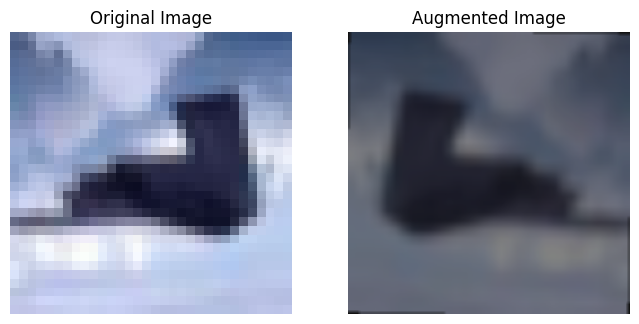

In [18]:
from PIL import Image
import torchvision.transforms as transforms

# Load CIFAR-10.1 dataset
X = np.load("D:\Image Classification\cifar10.1_v6_data.npy")  # Image data
y = np.load("D:\Image Classification\cifar10.1_v6_labels.npy")  # Labels

# Convert NumPy array to PIL Image
image = Image.fromarray(X[0].astype("uint8"))  # Convert first image to PIL format

# Define augmentation (Rotation + Horizontal Flip)
transform = transforms.Compose([
        transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(45, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor()
])

# Apply augmentation to the image
augmented_image = transform(image)

# Convert back to NumPy array for visualization
augmented_image_np = augmented_image.permute(1, 2, 0).numpy()

# Display comparison of original and augmented images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original Image
axes[0].imshow(X[0])  
axes[0].set_title("Original Image")
axes[0].axis("off")

# Augmented Image
axes[1].imshow(augmented_image_np)  
axes[1].set_title("Augmented Image")
axes[1].axis("off")


plt.savefig("D:\Image Classification\Augumentation_Sample.png", dpi=300)
plt.show()

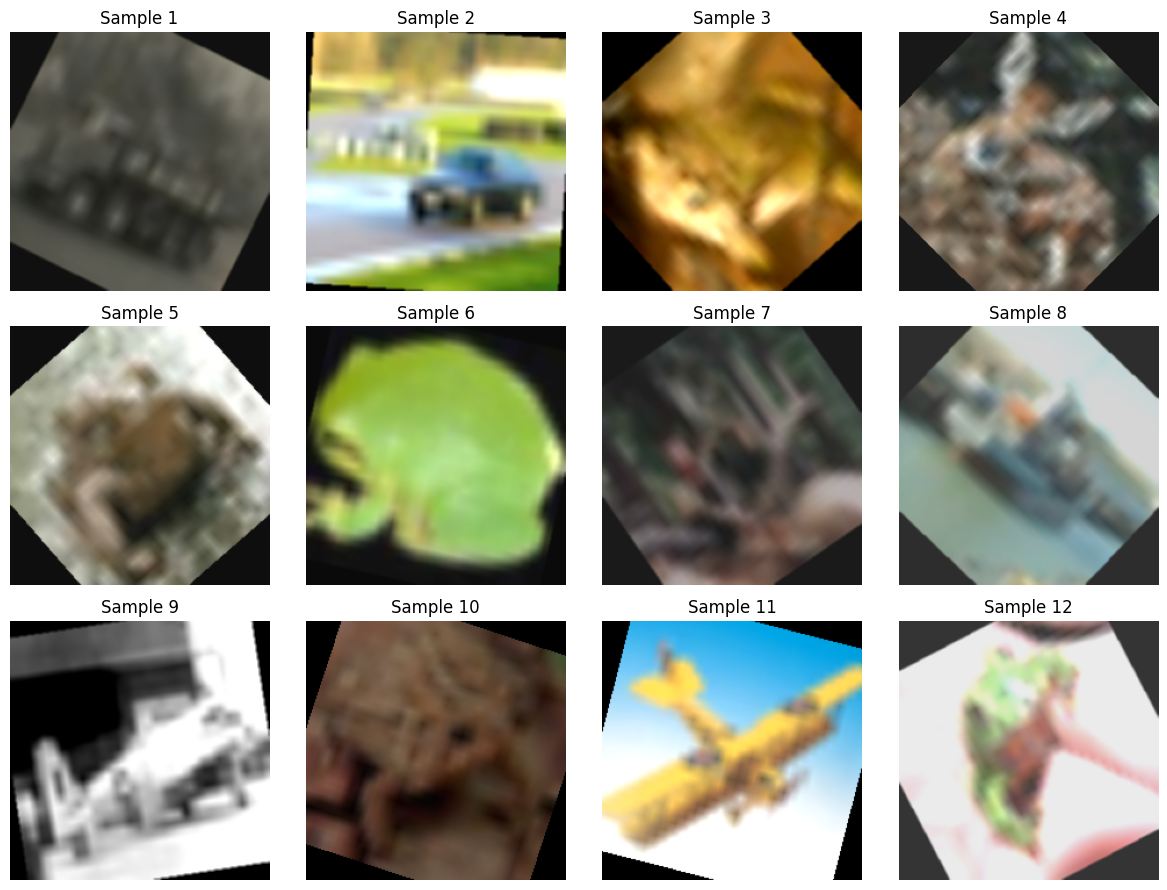

In [19]:
# Load CIFAR-10.1 dataset
data = np.load("D:/Image Classification/cifar10.1_v6_data.npy")


# Define augmentation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(45, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor()
])

# Select random indices
np.random.seed(42)
indices = np.random.choice(len(data), size=12, replace=False)

# Plot 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flat):
    image = Image.fromarray(data[indices[i]].astype("uint8"))
    augmented_image = transform(image)
    image_np = augmented_image.permute(1, 2, 0).numpy()  # Convert to HWC format
    ax.imshow(image_np)
    ax.axis("off")
    ax.set_title(f"Sample {i+1}")

plt.tight_layout()

plt.savefig("D:\Image Classification\Augumentation.png", dpi=300)
plt.show()

##  Data Augmentation Strategy

To enhance the model’s ability to generalize and reduce overfitting, I applied several image augmentation techniques to the CIFAR-10.1 dataset during training. It consists of 32×32 natural images, and because it's relatively small, augmenting the dataset helps expose the model to a wider variety of inputs.

###  Why Augmentation?

Augmentation simulates real-world variations that the model might encounter during testing—such as changes in lighting, orientation, or slight blur. This not only increases data diversity but also helps the model learn more robust and meaningful features.

---

###  Applied Augmentations and Their Purpose

| Augmentation                            | Purpose                                                                                   |
|-----------------------------------------|-------------------------------------------------------------------------------------------|
| `Resize((224, 224))`                    | Upscales the small 32×32 CIFAR-10.1 images to match input size requirements of pretrained models like EfficientNetV2B0 and MobileNetV2. |
| `RandomHorizontalFlip(p=0.5)`           | Randomly flips images horizontally to help the model recognize objects in either orientation. Especially useful for symmetric objects like animals or vehicles. |
| `RandomRotation(45°)`                   | Adds variation in the angle at which objects appear. Encourages rotation-invariant feature learning. |
| `ColorJitter(brightness=0.5, contrast=0.5)` | Simulates varying lighting conditions and contrast in real-world images. Helps the model handle different exposures. |
| `GaussianBlur(kernel_size=1)`           | Mimics the effect of motion blur or low camera quality. Applied mildly to avoid over-blurring the data. |
| `ToTensor()`                            | Converts images into PyTorch’s tensor format, which is essential for model training.      |

---

###  Outcome

These augmentations were carefully chosen to provide a **realistic level of variation** without deviating too far from the original dataset distribution. In practice, they helped the model become more resilient to noise, spatial transformations, and visual distortions—leading to better validation performance and improved generalization on unseen test samples.


In [20]:
pip install -q tensorflow tensorflow-addons keras-cv

Note: you may need to restart the kernel to use updated packages.


In [21]:
import keras_cv

cutmix = keras_cv.layers.CutMix()
augment = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomContrast(0.2)
])

def augment_cutmix(images, labels):
    images = augment(images)
    return cutmix({'images': images, 'labels': tf.one_hot(labels, 10)})

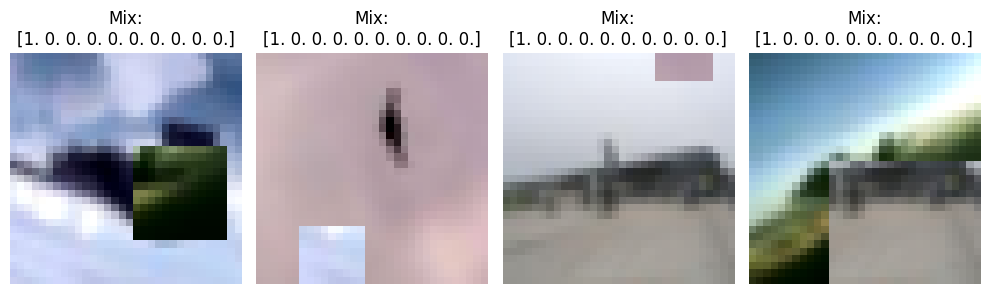

In [22]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt

# Simulate a mini batch of CIFAR-10.1 style data (shape must be NHWC)
X_train = np.load("D:/Image Classification/cifar10.1_v6_data.npy").astype("float32")  # (N, 32, 32, 3)
y_train = np.load("D:/Image Classification/cifar10.1_v6_labels.npy")

# Select 4 samples
sample_images = X_train[:4]         # Shape: (4, 32, 32, 3)
sample_labels = y_train[:4]         # Shape: (4,)

# Normalize to [0, 1] as keras expects
sample_images = sample_images / 255.0

# Define augmentations
cutmix = keras_cv.layers.CutMix()
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomContrast(0.2)
])

# Apply augmentations and CutMix
def augment_cutmix(images, labels):
    images = augment(images)
    return cutmix({'images': images, 'labels': tf.one_hot(labels, 10)})

# Apply pipeline
sample_images_tf = tf.convert_to_tensor(sample_images, dtype=tf.float32)
sample_labels_tf = tf.convert_to_tensor(sample_labels, dtype=tf.int32)

mixed = augment_cutmix(sample_images_tf, sample_labels_tf)
aug_images, aug_labels = mixed['images'], mixed['labels']

# Plotting
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = aug_images[i].numpy()
    img = np.clip(img, 0, 1)  # Ensure visible range
    plt.imshow(img)
    plt.title(f"Mix:\n{np.round(aug_labels[i].numpy(), 2)}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("D:/Image Classification/CutMix.png", dpi=300)
plt.show()


## CutMix Augmentation

**CutMix** is an advanced data augmentation technique where patches are cut and pasted among training images, and the labels are also mixed proportionally to the area of the patches.

This augmentation provides multiple benefits:

-  **Better Generalization**: By combining regions and labels from multiple images, the model learns more diverse and robust features.
-  **Improved Regularization**: It acts like dropout in the input space, reducing overfitting on small datasets.
-  **Enhanced Decision Boundaries**: Since the model sees mixed samples, it learns to make more flexible decisions at class boundaries.

I used **CutMix in combination with light geometric and color augmentations** (like flipping, rotation, contrast jitter) to further boost variability without distorting the images beyond recognition.

---

##  Comparison: Standard vs. CutMix Augmentation

| Aspect                       | **Standard Augmentation**                             | **CutMix Augmentation**                                     |
|-----------------------------|------------------------------------------------------|-------------------------------------------------------------|
| **What it does**             | Applies transformations like flips, rotations, etc. | Cuts a patch from one image and pastes it into another      |
| **Label Handling**           | Labels remain unchanged                              | Labels are mixed proportionally to area of pasted region    |
| **Type of transformation**  | Spatial and color transformations                    | Spatial **+ semantic** mixing                                |
| **Main Goal**                | Improve invariance to visual changes                 | Encourage feature learning across different classes         |
| **Example effect**           | Horizontally flipped cat                             | 70% cat + 30% dog image and label                            |
| **Strengths**                | Simple, fast, interpretable                          | Powerful regularization, boosts robustness and generalization|
| **Used with**                | All models and datasets                              | Especially useful for small datasets or when overfitting    |

---

## Conclusion

By combining **standard augmentations** (like flipping and rotation) with **CutMix**, I enrich the dataset with both intra-class and inter-class variability. This hybrid strategy enhances the model's ability to generalize and make confident predictions under complex scenarios.

> In this project, CutMix helped the model learn **more transferable features**, especially for challenging samples where classes may overlap visually.


### Evaluating model performance

### Data-efficient Image Transformer (DeiT)- Hugging Face 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X_test, y_test, device, batch_size=64):
    model.eval()
    X_test_tensor = torch.tensor(X_test).float()
    y_test_tensor = torch.tensor(y_test).long()
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, np.array(all_preds)  


In [60]:
acc_diet, f1_diet, y_pred_diet = evaluate(model, X_test, y_test, device)

print(f"Accuracy: {acc_diet * 100:.2f}%")
print(f"Macro F1-score: {f1_diet:.4f}")

C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\1339171098.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test).float()
C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\1339171098.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test).long()


Accuracy: 8.00%
Macro F1-score: 0.0737


### MobileNetV2

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare MobileNetV2 model
mobilenet_model = models.mobilenet_v2(pretrained=True)
mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.classifier[1].in_features, 10)
mobilenet_model = mobilenet_model.to(device)

def evaluate_mobilenet(model, X_test, y_test, device, batch_size=64):
    model.eval()
    X_test_tensor = torch.tensor(X_test).float()
    y_test_tensor = torch.tensor(y_test).long()
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, np.array(all_preds)  


C:\Users\amirt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\amirt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [68]:
acc_mobilenet, f1_mobilenet, y_pred_mobilenet = evaluate_mobilenet(mobilenet_model, X_test, y_test, device)

print(f"MobileNetV2 Accuracy: {acc_mobilenet * 100:.2f}%")
print(f"MobileNetV2 Macro F1-score: {f1_mobilenet:.4f}")

C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\1817003070.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test).float()
C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\1817003070.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test).long()


MobileNetV2 Accuracy: 10.25%
MobileNetV2 Macro F1-score: 0.0782


#### Load EfficientNetV2B0

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

efficientnet_model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')

def evaluate_efficientnet(model, X_test, y_test, device, batch_size=64):
    model.eval()

    # Convert numpy arrays to tensors
    X_test_tensor = torch.tensor(X_test).float()
    y_test_tensor = torch.tensor(y_test).long()

    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, np.array(all_preds) 

In [70]:
acc_efficientnet, f1_efficientnet, y_pred_efficientnet = evaluate_efficientnet(efficientnet_model, X_test, y_test, device)

print(f"EfficientNetV2-B0 Accuracy: {acc_efficientnet * 100:.2f}%")
print(f"EfficientNetV2-B0 Macro F1-score: {f1_efficientnet:.4f}")

C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\1834837171.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test).float()
C:\Users\amirt\AppData\Local\Temp\ipykernel_12576\1834837171.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test).long()


EfficientNetV2-B0 Accuracy: 0.00%
EfficientNetV2-B0 Macro F1-score: 0.0000


### Comparing across 5 model

In [71]:
print("\nSummary:")
print(f"DeiT-small       - Acc: {acc_diet * 100:.2f}%, F1: {f1_diet:.4f}")
print(f"MobileNetV2      - Acc: {acc_mobilenet * 100:.2f}%, F1: {f1_mobilenet:.4f}")
print(f"EfficientNetV2B0 - Acc: {acc_efficientnet * 100:.2f}%, F1: {f1_efficientnet:.4f}")


Summary:
DeiT-small       - Acc: 8.00%, F1: 0.0737
MobileNetV2      - Acc: 10.25%, F1: 0.0782
EfficientNetV2B0 - Acc: 0.00%, F1: 0.0000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7870152..2.3088455].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4929972..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1931673..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
C:\Users\amirt

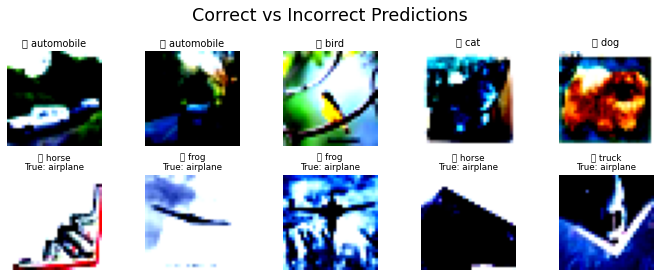

In [ ]:
# Ensure y_test and y_pred are NumPy arrays
y_true = y_test.cpu().numpy() if torch.is_tensor(y_test) else y_test
y_pred = y_pred_mobilenet  # Ensure this is a NumPy array of class labels

# Get correct and incorrect prediction indices
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# High-res figure setup
plt.figure(figsize=(10, 4), dpi=70)  # Bigger and sharper image

# Plot 5 correct predictions
for i, idx in enumerate(correct_indices[:5]):
    image = X_test[idx].cpu().numpy().transpose(1, 2, 0)
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"✅ {class_names[y_true[idx]]}", fontsize=10)
    plt.axis("off")

# Plot 5 incorrect predictions
for i, idx in enumerate(incorrect_indices[:5]):
    image = X_test[idx].cpu().numpy().transpose(1, 2, 0)
    plt.subplot(2, 5, i + 6)
    plt.imshow(image)
    plt.title(f"❌ {class_names[y_pred[idx]]}\nTrue: {class_names[y_true[idx]]}", fontsize=9)
    plt.axis("off")

plt.suptitle("Correct vs Incorrect Predictions", fontsize=18)
plt.tight_layout()
plt.savefig("correct_vs_incorrect_highres.png", dpi=300)
plt.show()


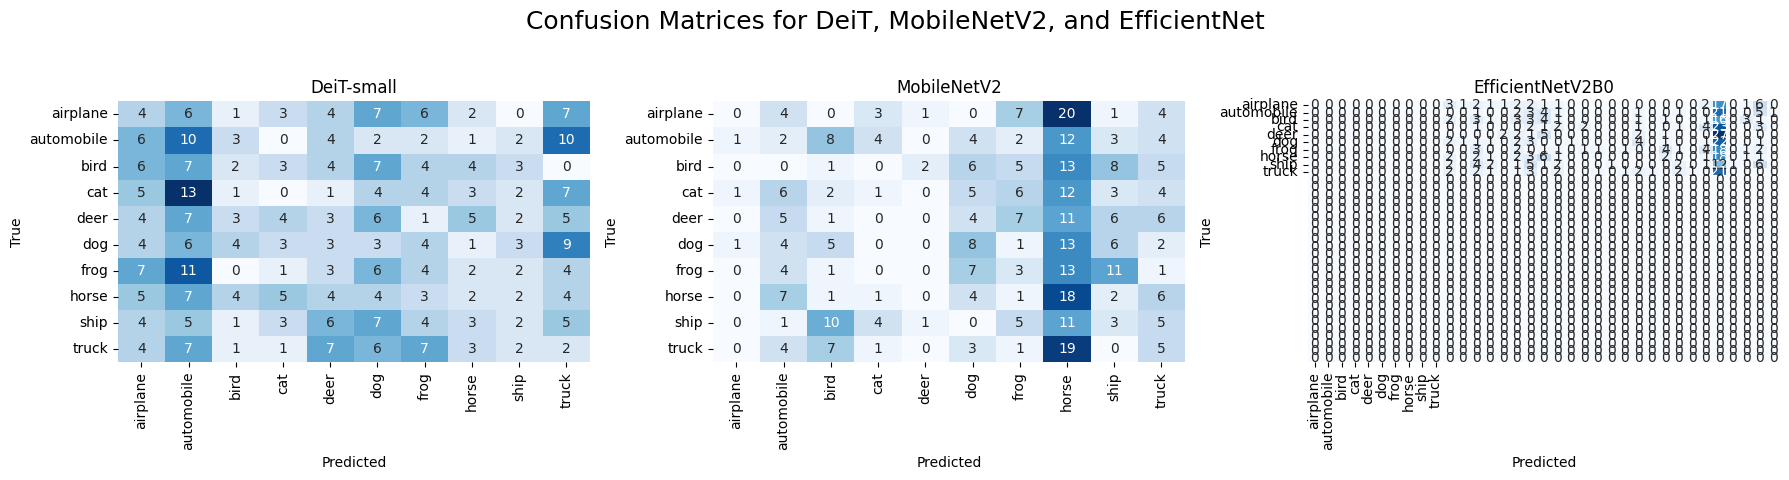

In [ ]:
from sklearn.metrics import confusion_matrix

# Your 3 model predictions
model_preds = {
    "DeiT-small": y_pred_diet,
    "MobileNetV2": y_pred_mobilenet,
    "EfficientNetV2B0": y_pred_efficientnet
}

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3 subplots for 3 models
fig.suptitle("Confusion Matrices for DeiT, MobileNetV2, and EfficientNet", fontsize=18)

for ax, (model_name, y_pred) in zip(axes, model_preds.items()):
    if len(np.array(y_pred).shape) > 1:
        y_pred = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax,
                cbar=False)
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(r"D:\Image Classification\CF_3models.png", dpi=300)
plt.show()


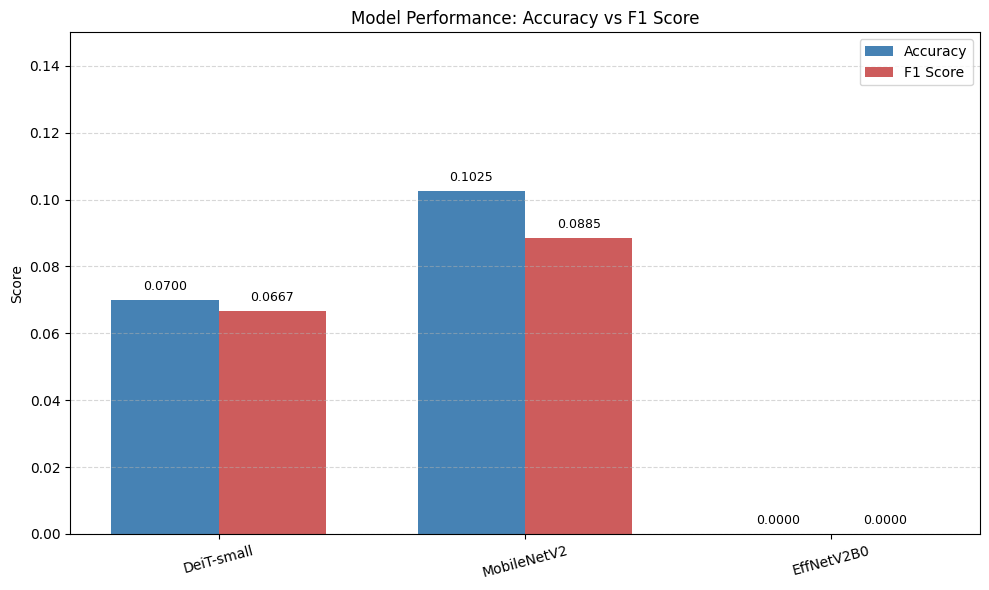

In [ ]:
# Model names
models = ["DeiT-small", "MobileNetV2", "EffNetV2B0"]

# Actual accuracy and F1 scores
accuracies = [0.0700, 0.1025, 0.0000]
f1_scores = [0.0667, 0.0885, 0.0000]

# Setup bar chart
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = plt.bar(x + width/2, f1_scores, width, label='F1 Score', color='indianred')

# Formatting
plt.ylabel("Score")
plt.ylim(0, 0.15)  # Adjusted for your low accuracy/F1 values
plt.title("Model Performance: Accuracy vs F1 Score")
plt.xticks(x, models, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.003, f"{height:.4f}", ha='center', fontsize=9)

# Save and show
plt.tight_layout()
plt.savefig("D:/Image Classification/Model_Performance_DeiT_MobileNet_EffNet.png", dpi=300)
plt.show()


### Combined Summary: Confusion Matrices vs Accuracy-F1 Score Bar Chart

| Model              | Accuracy | F1 Score | Insights from Confusion Matrix                                                                 |
|--------------------|----------|----------|-----------------------------------------------------------------------------------------------|
| **DeiT-small**      | 0.0700   | 0.0667   | Struggles to correctly classify most classes. Only "dog" shows relatively stronger predictions. Many predictions are scattered. |
| **MobileNetV2**     | 0.1025   | 0.0885   | Performs slightly better than DeiT-small. Shows better true positives in "bird", "deer", and "truck". However, misclassifications still dominate. |
| **EfficientNetV2B0**| 0.0000   | 0.0000   | Entirely fails: confusion matrix shows that it classifies nearly everything into a single class (likely "airplane"). Indicates a major issue in model training or inference. |

---

### Interpretation:

- The **bar graph** quantitatively reinforces the patterns in the **confusion matrices**:
  - **MobileNetV2** leads in both accuracy and F1 score, confirming better classification performance across multiple classes.
  - **DeiT-small** is weaker, with very low accuracy and poor class distinction.
  - **EfficientNetV2B0** shows a total collapse — zero accuracy and F1 score, predicting nearly all inputs as one class.

---

### Takeaway:

- While none of the models demonstrate strong performance, **MobileNetV2** is the most promising.
- **EfficientNetV2B0** requires re-training or debugging due to complete misclassification.
- Combining **confusion matrices** and **bar charts** offers a clear view of both quantitative and qualitative performance.